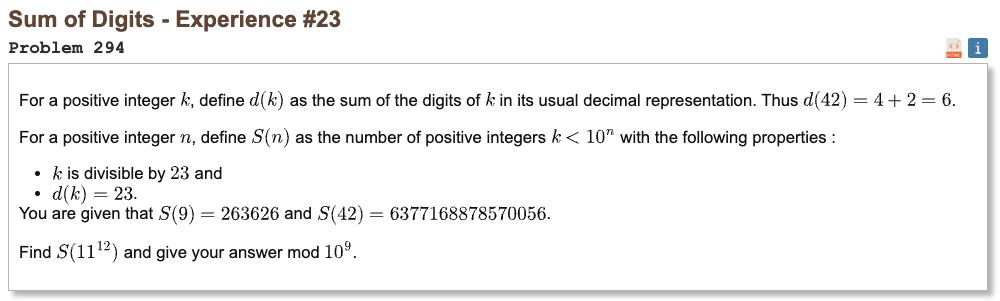

## Initial approach

* treat the number as a string of exactly n digits with leading zeros allowed, because the digit sum target already excludes the all zero case
* each digit position affects two things at once, the running digit sum and the remainder modulo 23
* modulo 23, the place values repeat every 22 positions, so the huge length can be compressed into repeated 22 digit blocks
* build one small polynomial style state object for a single position, then multiply these objects to combine positions
* keep only digit sums up to 23 the whole time, because anything larger can never help
* first build the full 22 position block, then raise that block to a huge power with fast exponentiation
* multiply once more by the leftover first 11 positions, since 11 to any positive power leaves remainder 11 when divided by 22
* the final answer is the state with digit sum 23 and remainder 0, taken modulo one billion

In [1]:
MOD = 10**9
TARGET_SUM = 23
MODULO = 23

def multiply(a, b):
    res = [[0] * MODULO for _ in range(TARGET_SUM + 1)]
    for sa in range(TARGET_SUM + 1):
        row_a = a[sa]
        for sb in range(TARGET_SUM - sa + 1):
            row_b = b[sb]
            out = res[sa + sb]
            for ra in range(MODULO):
                va = row_a[ra]
                if va == 0:
                    continue
                for rb in range(MODULO):
                    vb = row_b[rb]
                    if vb == 0:
                        continue
                    out[(ra + rb) % MODULO] = (out[(ra + rb) % MODULO] + va * vb) % MOD
    return res

def power(poly, exp):
    result = [[0] * MODULO for _ in range(TARGET_SUM + 1)]
    result[0][0] = 1
    base = poly
    e = exp
    while e > 0:
        if e & 1:
            result = multiply(result, base)
        base = multiply(base, base)
        e >>= 1
    return result

def single_position(weight):
    poly = [[0] * MODULO for _ in range(TARGET_SUM + 1)]
    for d in range(10):
        if d <= TARGET_SUM:
            poly[d][(weight * d) % MODULO] += 1
    return poly

def solve(n):
    weights = []
    w = 1
    for _ in range(22):
        weights.append(w)
        w = (w * 10) % MODULO

    block = [[0] * MODULO for _ in range(TARGET_SUM + 1)]
    block[0][0] = 1
    for w in weights:
        block = multiply(block, single_position(w))

    q, r = divmod(n, 22)

    result = power(block, q)

    for i in range(r):
        result = multiply(result, single_position(weights[i]))

    return result[TARGET_SUM][0] % MOD

assert solve(9) == 263626
assert solve(42) == 6377168878570056 % MOD

In [2]:
%%time
result = solve(11**12)
print("Result:", result)

Result: 789184709
CPU times: user 775 ms, sys: 4.86 ms, total: 780 ms
Wall time: 779 ms
